x: [ 0.1037873   2.68177562  1.59275856 -1.30562494 -1.67372782]
y: [ 3.03016904 10.2108257   4.06583525  0.5351681   3.87773453]
**************************************************
x reshaped: [[ 0.1037873 ]
 [ 2.68177562]
 [ 1.59275856]
 [-1.30562494]
 [-1.67372782]]
**************************************************
mean squared error: 3.190170974414723
**************************************************


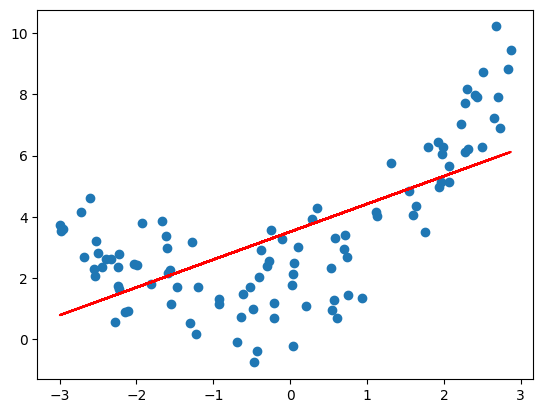

In [ ]:
# underfitting

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Lasso, Ridge

np.random.seed(23)
x = np.random.uniform(-3, 3, size=100)
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, size=100)

print(f'x: {x[:5]}')
print(f'y: {y[:5]}')
print('*' * 50)

x_reshaped = x.reshape(-1, 1)
print(f'x reshaped: {x_reshaped[:5]}')
print('*' * 50)

estimator = LinearRegression()
estimator.fit(x_reshaped, y)
y_pred = estimator.predict(x_reshaped)

print(f'mean squared error: {mean_squared_error(y, y_pred)}')
print('*' * 50)

plt.scatter(x, y)
plt.plot(x, y_pred, color='red')
plt.show()


x: [ 0.1037873   2.68177562  1.59275856 -1.30562494 -1.67372782]
y: [ 3.03016904 10.2108257   4.06583525  0.5351681   3.87773453]
**************************************************
x reshaped: [[ 0.1037873 ]
 [ 2.68177562]
 [ 1.59275856]
 [-1.30562494]
 [-1.67372782]]
**************************************************
x hstacked: [[ 0.1037873   0.0107718 ]
 [ 2.68177562  7.19192049]
 [ 1.59275856  2.53687982]
 [-1.30562494  1.70465647]
 [-1.67372782  2.80136482]]
**************************************************
mean squared error: 1.0934609127807469
**************************************************


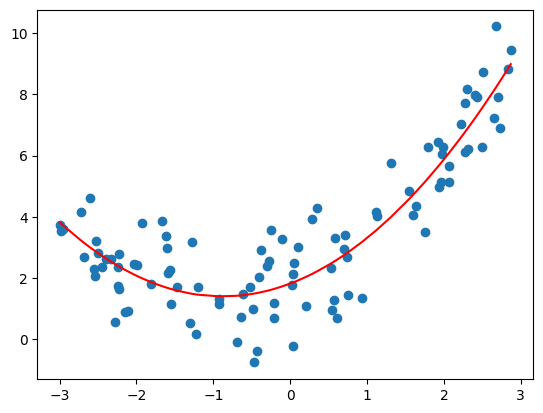

In [ ]:
# justfitting

# 有高次特征时，预测曲线有弯曲，需要对特征列进行排序，否则plt.plot会按随机顺序连点，曲线会来回折返

np.random.seed(23)
x = np.random.uniform(-3, 3, 100)
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, 100)

print(f'x: {x[:5]}')
print(f'y: {y[:5]}')
print('*' * 50)

x_reshaped = x.reshape(-1, 1)
print(f'x reshaped: {x_reshaped[:5]}')
print('*' * 50)

x_hstacked = np.hstack([x_reshaped, x_reshaped ** 2])  # 增加一个二次项特征列
print(f'x hstacked: {x_hstacked[:5]}')
print('*' * 50)

estimator = LinearRegression()
estimator.fit(x_hstacked, y)
y_pred = estimator.predict(x_hstacked)

print(f'mean squared error: {mean_squared_error(y, y_pred)}')
print('*' * 50)

plt.scatter(x, y)
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red')
plt.show()



x: [ 0.1037873   2.68177562  1.59275856 -1.30562494 -1.67372782]
y: [ 3.03016904 10.2108257   4.06583525  0.5351681   3.87773453]
**************************************************
x reshaped: [[ 0.1037873 ]
 [ 2.68177562]
 [ 1.59275856]
 [-1.30562494]
 [-1.67372782]]
**************************************************
x all: [[ 1.03787303e-01  1.07718043e-02  1.11797652e-03  1.16031767e-04
   1.20426242e-05  1.24987149e-06  1.29720791e-07  1.34633711e-08
   1.39732697e-09  1.45024798e-10]
 [ 2.68177562e+00  7.19192049e+00  1.92871171e+01  5.17237204e+01
   1.38711412e+02  3.71992884e+02  9.97601449e+02  2.67534325e+03
   7.17467030e+03  1.92408559e+04]
 [ 1.59275856e+00  2.53687982e+00  4.04063704e+00  6.43575922e+00
   1.02506106e+01  1.63267477e+01  2.60045671e+01  4.14189967e+01
   6.59704614e+01  1.05075017e+02]
 [-1.30562494e+00  1.70465647e+00 -2.22564200e+00  2.90585369e+00
  -3.79395504e+00  4.95348231e+00 -6.46739003e+00  8.44398569e+00
  -1.10246783e+01  1.43940949e+01]
 [-1.

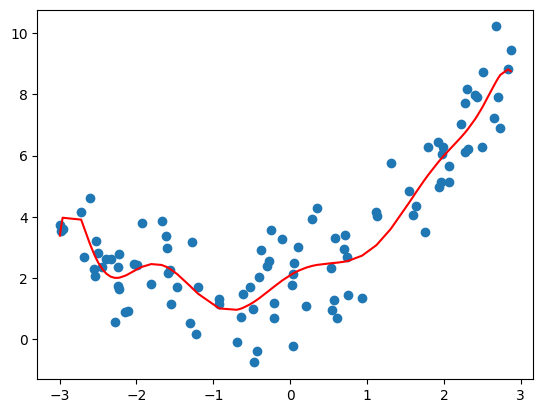

In [ ]:
# overfitting

np.random.seed(23)
x = np.random.uniform(-3, 3, 100)
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, 100)

print(f'x: {x[:5]}')
print(f'y: {y[:5]}')
print('*' * 50)

x_reshaped = x.reshape(-1, 1)
print(f'x reshaped: {x_reshaped[:5]}')
print('*' * 50)

x_all = np.hstack([x_reshaped, x_reshaped ** 2, x_reshaped ** 3, x_reshaped ** 4, x_reshaped ** 5, x_reshaped ** 6, x_reshaped ** 7, x_reshaped ** 8, x_reshaped ** 9, x_reshaped ** 10])  # 增加更多的高次项特征列

print(f'x all: {x_all[:5]}')
print('*' * 50)

estimator = LinearRegression()
estimator.fit(x_all, y)
y_pred = estimator.predict(x_all)

print(f'mean squared error: {mean_squared_error(y, y_pred)}')
print('*' * 50)

plt.scatter(x, y)
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red')
plt.show()



x: [ 0.1037873   2.68177562  1.59275856 -1.30562494 -1.67372782]
y: [ 3.03016904 10.2108257   4.06583525  0.5351681   3.87773453]
**************************************************
x reshaped: [[ 0.1037873 ]
 [ 2.68177562]
 [ 1.59275856]
 [-1.30562494]
 [-1.67372782]]
**************************************************
x all: [[ 1.03787303e-01  1.07718043e-02  1.11797652e-03  1.16031767e-04
   1.20426242e-05  1.24987149e-06  1.29720791e-07  1.34633711e-08
   1.39732697e-09  1.45024798e-10]
 [ 2.68177562e+00  7.19192049e+00  1.92871171e+01  5.17237204e+01
   1.38711412e+02  3.71992884e+02  9.97601449e+02  2.67534325e+03
   7.17467030e+03  1.92408559e+04]
 [ 1.59275856e+00  2.53687982e+00  4.04063704e+00  6.43575922e+00
   1.02506106e+01  1.63267477e+01  2.60045671e+01  4.14189967e+01
   6.59704614e+01  1.05075017e+02]
 [-1.30562494e+00  1.70465647e+00 -2.22564200e+00  2.90585369e+00
  -3.79395504e+00  4.95348231e+00 -6.46739003e+00  8.44398569e+00
  -1.10246783e+01  1.43940949e+01]
 [-1.

/home/yj/miniconda3/envs/ml/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.801e+01, tolerance: 5.772e-02
  model = cd_fast.enet_coordinate_descent(


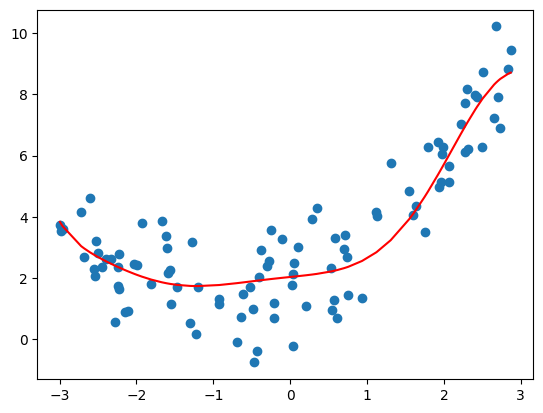

In [ ]:
# l1 regularization (lasso)，减小权重，可以为0

np.random.seed(23)
x = np.random.uniform(-3, 3, 100)
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, 100)

print(f'x: {x[:5]}')
print(f'y: {y[:5]}')
print('*' * 50)

x_reshaped = x.reshape(-1, 1)
print(f'x reshaped: {x_reshaped[:5]}')
print('*' * 50)

x_all = np.hstack([x_reshaped, x_reshaped ** 2, x_reshaped ** 3, x_reshaped ** 4, x_reshaped ** 5, x_reshaped ** 6, x_reshaped ** 7, x_reshaped ** 8, x_reshaped ** 9, x_reshaped ** 10])  # 增加更多的高次项特征列

print(f'x all: {x_all[:5]}')
print('*' * 50)

estimator = Lasso(alpha=0.1)
estimator.fit(x_all, y)
y_pred = estimator.predict(x_all)

print(f'mean squared error: {mean_squared_error(y, y_pred)}')
print('*' * 50)

plt.scatter(x, y)
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red')
plt.show()



x: [ 0.1037873   2.68177562  1.59275856 -1.30562494 -1.67372782]
y: [ 3.03016904 10.2108257   4.06583525  0.5351681   3.87773453]
**************************************************
x reshaped: [[ 0.1037873 ]
 [ 2.68177562]
 [ 1.59275856]
 [-1.30562494]
 [-1.67372782]]
**************************************************
x all: [[ 1.03787303e-01  1.07718043e-02  1.11797652e-03  1.16031767e-04
   1.20426242e-05  1.24987149e-06  1.29720791e-07  1.34633711e-08
   1.39732697e-09  1.45024798e-10]
 [ 2.68177562e+00  7.19192049e+00  1.92871171e+01  5.17237204e+01
   1.38711412e+02  3.71992884e+02  9.97601449e+02  2.67534325e+03
   7.17467030e+03  1.92408559e+04]
 [ 1.59275856e+00  2.53687982e+00  4.04063704e+00  6.43575922e+00
   1.02506106e+01  1.63267477e+01  2.60045671e+01  4.14189967e+01
   6.59704614e+01  1.05075017e+02]
 [-1.30562494e+00  1.70465647e+00 -2.22564200e+00  2.90585369e+00
  -3.79395504e+00  4.95348231e+00 -6.46739003e+00  8.44398569e+00
  -1.10246783e+01  1.43940949e+01]
 [-1.

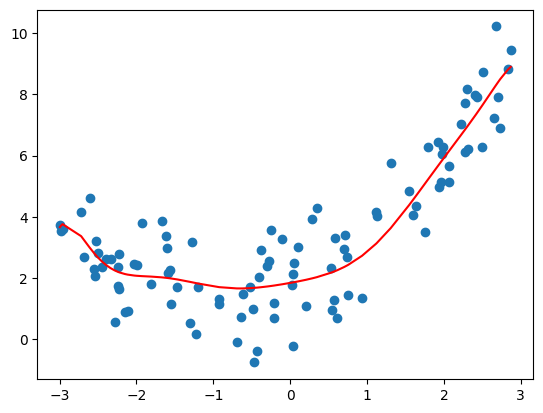

In [ ]:
# l2 regularization (ridge)，减小权重，但不会为0

np.random.seed(23)
x = np.random.uniform(-3, 3, 100)
y = 0.5 * x ** 2 + x + 2 + np.random.normal(0, 1, 100)

print(f'x: {x[:5]}')
print(f'y: {y[:5]}')
print('*' * 50)

x_reshaped = x.reshape(-1, 1)
print(f'x reshaped: {x_reshaped[:5]}')
print('*' * 50)

x_all = np.hstack([x_reshaped, x_reshaped ** 2, x_reshaped ** 3, x_reshaped ** 4, x_reshaped ** 5, x_reshaped ** 6, x_reshaped ** 7, x_reshaped ** 8, x_reshaped ** 9, x_reshaped ** 10])  # 增加更多的高次项特征列

print(f'x all: {x_all[:5]}')
print('*' * 50)

# estimator = Ridge(alpha=0.1)
estimator = Ridge(alpha=10)
estimator.fit(x_all, y)
y_pred = estimator.predict(x_all)

print(f'mean squared error: {mean_squared_error(y, y_pred)}')
print('*' * 50)

plt.scatter(x, y)
plt.plot(np.sort(x), y_pred[np.argsort(x)], color='red')
plt.show()

